# 🖥️ Laptop Price Prediction — SVM Regression Pipeline

---

## Step 1 · Import Libraries
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.dummy import DummyRegressor

In [2]:
Dataset_Path = r'C:\Users\TLMO\Downloads\laptop_price_dataset.csv'
df = pd.read_csv(Dataset_Path)

In [3]:
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

Rows: 12,000  |  Columns: 26


---

## Step 2 · Split Data

> **Why split first?**  
> To Avoid Data Leakage
---

In [4]:
TARGET = 'price_usd'

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Target       : '{TARGET}'  (dtype: {y.dtype})")


Training set : 9,600 samples
Test set     : 2,400 samples
Target       : 'price_usd'  (dtype: float64)


---

## Step 3 · Exploratory Data Analysis (EDA)
---

### Dataset Overview

We first examine the full dataset structure

In [5]:
print("=" * 15)
print("DATASET INFO")
print("=" * 15)
df.info()

print("\n" + "=" * 15)
print("STATISTICAL SUMMARY")
print("=" * 15)
display(df.describe(include='all').T)
display(df.isnull().sum().rename("Missing Count").to_frame())

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   brand               12000 non-null  str    
 1   category            12000 non-null  str    
 2   screen_size         12000 non-null  float64
 3   resolution          12000 non-null  str    
 4   cpu                 12000 non-null  str    
 5   gpu                 12000 non-null  str    
 6   ram_gb              12000 non-null  int64  
 7   storage_gb          12000 non-null  int64  
 8   storage_type        12000 non-null  str    
 9   operating_system    12000 non-null  str    
 10  year                12000 non-null  int64  
 11  weight_kg           12000 non-null  float64
 12  battery_wh          12000 non-null  int64  
 13  refresh_rate_hz     12000 non-null  int64  
 14  cpu_cores           12000 non-null  int64  
 15  touchscreen         12000 non-null  int64  
 16  ba

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,12000,10,Dell,2187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,12000,7,Notebook,3323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_size,12000.0,NaN,NaN,NaN,14.65565,1.874051,11.6,13.3,15.6,16.0,17.3
resolution,12000,6,1920x1080,5398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cpu,12000,12,Intel Core i5,2691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gpu,12000,10,Integrated,5687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ram_gb,12000.0,NaN,NaN,NaN,17.247667,14.030053,4.0,8.0,16.0,16.0,64.0
storage_gb,12000.0,NaN,NaN,NaN,609.6,443.480639,128.0,256.0,512.0,1024.0,2048.0
storage_type,12000,4,SSD,7236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operating_system,12000,6,Windows 11,5026,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Missing Count
brand,0
category,0
screen_size,0
resolution,0
cpu,0
gpu,0
ram_gb,0
storage_gb,0
storage_type,0
operating_system,0


---
## Distribution & Relationship Plots

All distribution and correlation analysis is computed on **`train_full` (training set only)** to avoid leakage.

### Price Distribution · Price by Brand · Price by Category · Correlation Heatmap
---

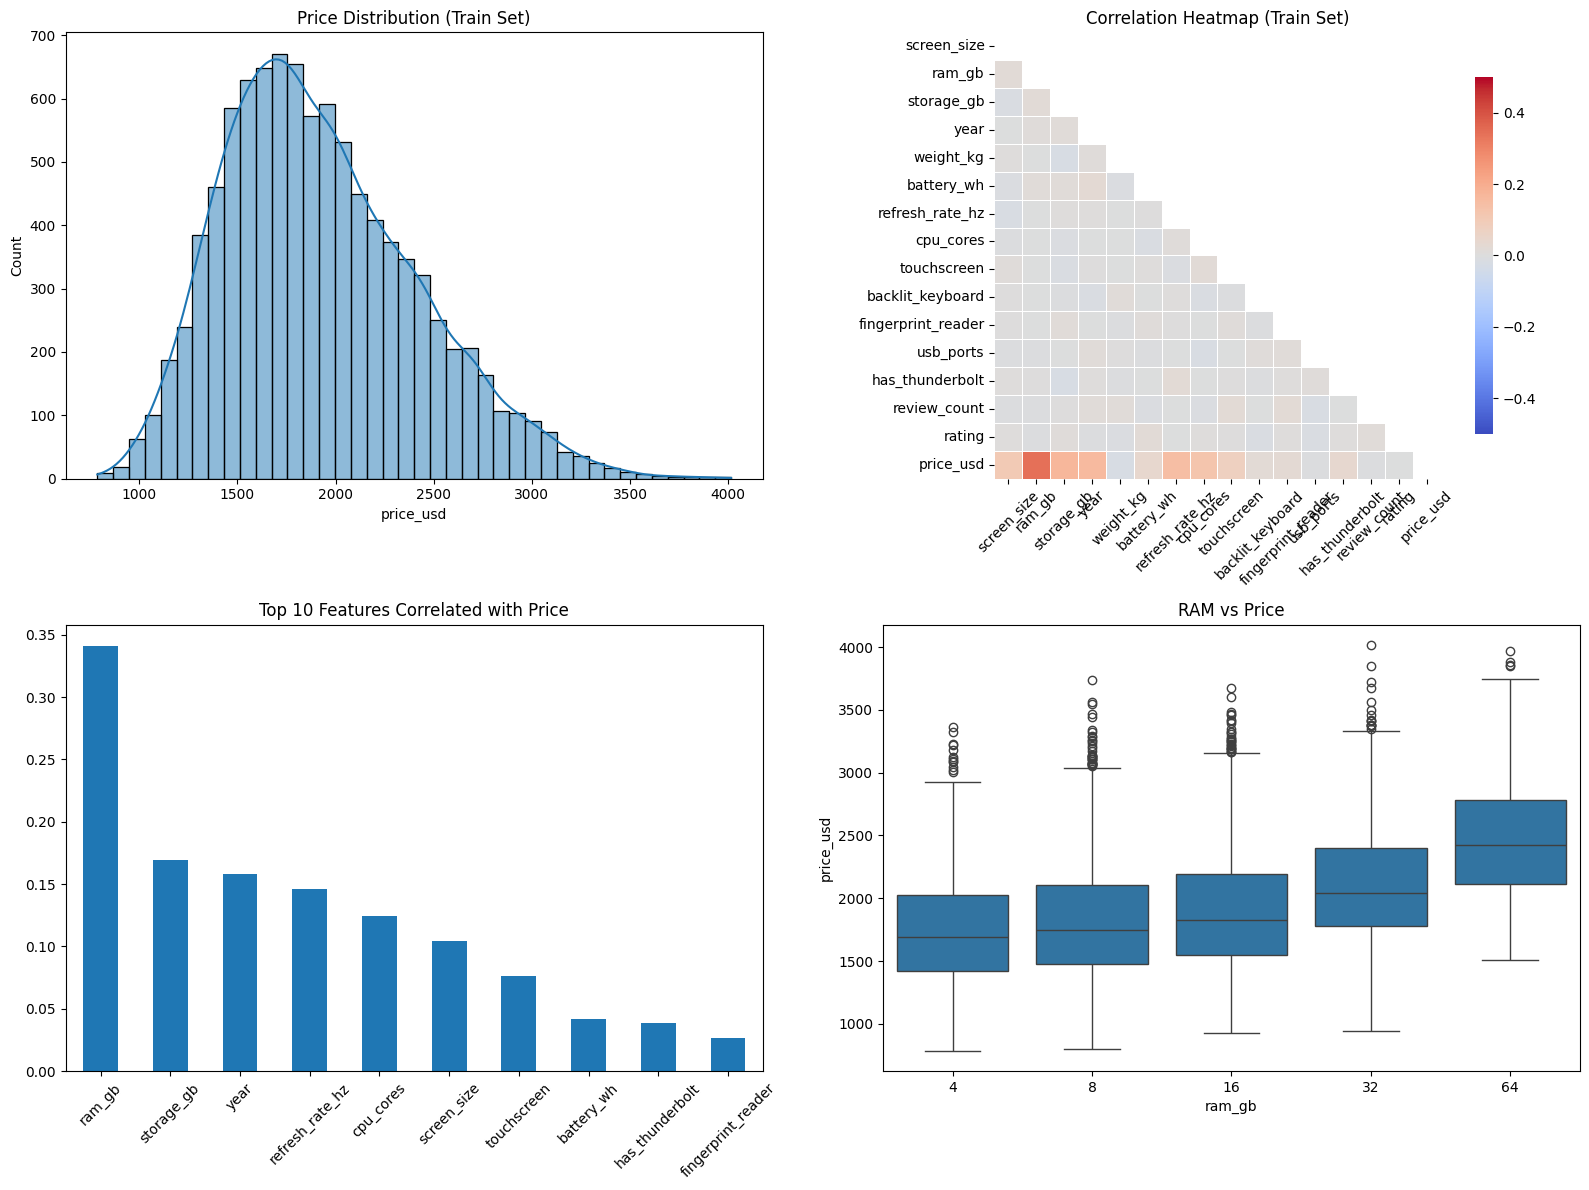

In [ ]:
train_full = X_train.copy()
train_full[TARGET] = y_train

num_train = train_full.select_dtypes(include=np.number)
corr = num_train.corr()
corr_target = corr[TARGET].sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Target distribution
sns.histplot(train_full[TARGET], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Price Distribution )")

# Correlation heatmap 
mask = np.triu(np.ones_like(corr, dtype=bool)) 

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-0.5, vmax=0.5,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=axes[1]
)

axes[1].set_title("Correlation Heatmap")
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

# Top correlations with target
corr_target.drop(TARGET).head(10).plot(kind='bar', ax=axes[2])
axes[2].set_title("Top 10 Features Correlated with Price")
axes[2].tick_params(axis='x', rotation=45)

# RAM vs Price
sns.boxplot(x='ram_gb', y=TARGET, data=train_full, ax=axes[3])
axes[3].set_title("RAM vs Price")

plt.tight_layout()
plt.show()

---
# Step 4: Data Cleaning
---

## Check For Missing Values

In [7]:
print("Missing in X_train:\n", X_train.isnull().sum()[X_train.isnull().sum() > 0])
print("Missing in X_test:\n",  X_test.isnull().sum()[X_test.isnull().sum() > 0])

Missing in X_train:
 Series([], dtype: int64)
Missing in X_test:
 Series([], dtype: int64)


# Check For Duplicates

In [8]:
print(f"Duplicates in training set: {X_train.duplicated().sum()}")

Duplicates in training set: 0


# Outlier Detection

In [9]:
num_check = ['price_usd','ram_gb','storage_gb','battery_wh','refresh_rate_hz',
             'weight_kg','screen_size','year','review_count']

train_check = X_train.copy(); train_check['price_usd'] = y_train
outlier_rows = []
for col in num_check:
    Q1  = train_check[col].quantile(0.25)
    Q3  = train_check[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((train_check[col] < lo) | (train_check[col] > hi)).sum()
    outlier_rows.append({'Feature': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                         'IQR Lower': round(lo,2), 'IQR Upper': round(hi,2),
                         'Outliers': n_out})

out_df = pd.DataFrame(outlier_rows)
display(out_df)
print("\n→ Outliers exist but represent valid real-world products.")
print("  Records are RETAINED – dropping them would bias the model against premium laptops.")

,Feature,Q1,Q3,IQR Lower,IQR Upper,Outliers
0,price_usd,1559.90,2238.36,542.22,3256.04,83
1,ram_gb,8.00,16.00,-4.00,28.00,2185
2,storage_gb,256.00,1024.00,-896.00,2176.00,0
3,battery_wh,47.00,82.00,-5.50,134.50,0
4,refresh_rate_hz,60.00,144.00,-66.00,270.00,0
5,weight_kg,1.61,3.08,-0.60,5.28,0
6,screen_size,13.30,16.00,9.25,20.05,0
7,year,2019.00,2023.00,2013.00,2029.00,0
8,review_count,1252.00,3767.00,-2520.50,7539.50,0



→ Outliers exist but represent valid real-world products.
  Records are RETAINED – dropping them would bias the model against premium laptops.


# Visualizing Outliers

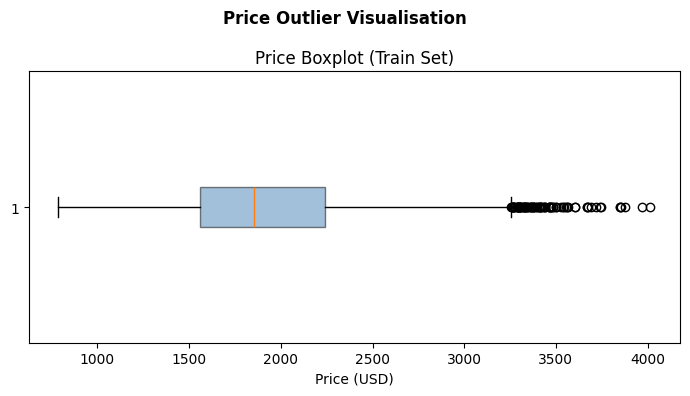

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

train_check = X_train.copy()
train_check['price_usd'] = y_train

ax.boxplot(train_check['price_usd'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.5))
ax.set_title('Price Boxplot')
ax.set_xlabel('Price (USD)')

plt.suptitle('Price Outlier Visualisation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Step 5 · Preprocessing Pipeline

Feature Definitions
---

In [11]:
num_cols = ['screen_size','ram_gb','storage_gb','year','weight_kg','battery_wh',
            'refresh_rate_hz','cpu_cores','touchscreen','backlit_keyboard',
            'fingerprint_reader','usb_ports','has_thunderbolt','review_count','rating']

cat_cols = ['brand','category','resolution','cpu','gpu','storage_type',
            'operating_system','color','country_of_origin','warranty']

print(f"Numeric features  : {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")
print(f"Total input features: {len(num_cols) + len(cat_cols)}")

Numeric features  : 15
Categorical features: 10
Total input features: 25


# Numeric Pipeline

In [12]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical Pipeline

In [13]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Creating Preprocessor ( Combining Numeric & Categorical Pipelines )

In [14]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

---

## Step 6 · Dimensionality Reduction — PCA

---

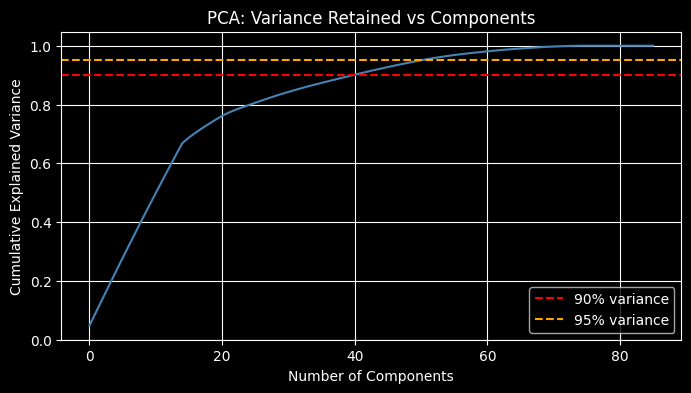

Components for 90%: 41  |  Components for 95%: 51
→ Both thresholds will be trialled inside GridSearchCV.


In [32]:
_pre = preprocessor.fit(X_train)
X_train_pp_temp = _pre.transform(X_train)

pca_explore = PCA().fit(X_train_pp_temp)
cumvar = np.cumsum(pca_explore.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(cumvar, color='steelblue')
plt.axhline(0.90, color='red',    linestyle='--', label='90% variance')
plt.axhline(0.95, color='orange', linestyle='--', label='95% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Variance Retained vs Components")
plt.legend(); plt.grid(True)
plt.show()

n90 = int(np.searchsorted(cumvar, 0.90)) + 1
n95 = int(np.searchsorted(cumvar, 0.95)) + 1
print(f"Components for 90%: {n90}  |  Components for 95%: {n95}")
print("→ Both thresholds will be trialled inside GridSearchCV.")

---

## Step 7 · Hyperparameter Tuning

---

In [33]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA()),
    ('svr', SVR())
])

param_grid = [
    {  # Linear kernel
        'pca__n_components': [0.90, 0.95],
        'svr__kernel': ['linear'],
        'svr__C': [0.1, 1, 10],
        'svr__epsilon': [0.01, 0.1, 0.2]
    },
    {  # RBF kernel
        'pca__n_components': [0.90, 0.95],
        'svr__kernel': ['rbf'],
        'svr__C': [1, 10, 50],
        'svr__epsilon': [0.01, 0.1],
        'svr__gamma': ['scale', 'auto']
    }
]

grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=5,   
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV R²      : {grid_search.best_score_:.4f}")
print(grid_search.best_params_['svr__kernel'])

Fitting 5 folds for each of 42 candidates, totalling 210 fits

Best parameters : {'pca__n_components': 0.95, 'svr__C': 10, 'svr__epsilon': 0.2, 'svr__kernel': 'linear'}
Best CV R²      : 0.7850
linear


# Best Model

In [34]:
cv_df = pd.DataFrame(grid_search.cv_results_)

cv_results = cv_df[
    ['param_pca__n_components',
     'param_svr__C',
     'param_svr__epsilon',
     'mean_test_score',
     'std_test_score',
     'rank_test_score']
].sort_values('rank_test_score').reset_index(drop=True)

cv_results.columns = [
    'PCA Components',
    'C',
    'Epsilon',
    'Mean CV R²',
    'Std CV R²',
    'Rank'
]

cv_results['Mean CV R²'] = cv_results['Mean CV R²'].round(4)
cv_results['Std CV R²'] = cv_results['Std CV R²'].round(4)

print("Top 10 parameter combinations:")
display(cv_results.head(10))

Top 10 parameter combinations:


,PCA Components,C,Epsilon,Mean CV R²,Std CV R²,Rank
0,0.95,10.0,0.20,0.7850,0.0051,1
1,0.95,10.0,0.01,0.7850,0.0051,2
2,0.95,10.0,0.10,0.7850,0.0051,3
3,0.95,1.0,0.10,0.7724,0.0057,4
4,0.95,1.0,0.20,0.7724,0.0057,5
5,0.95,1.0,0.01,0.7724,0.0057,6
6,0.95,50.0,0.01,0.7641,0.0063,7
7,0.95,50.0,0.10,0.7641,0.0063,8
8,0.95,50.0,0.10,0.7391,0.0077,9
9,0.95,50.0,0.01,0.7391,0.0077,10


---

## Step 8 · Final Model Evaluation

---

       FINAL TEST SET EVALUATION
  R²   (Coefficient of Determination) : 0.7724
  MAE  (Mean Absolute Error)           : $173.59
  RMSE (Root Mean Squared Error)       : $238.77

→ The model explains 77.2% of price variance.
→ On average, predictions are off by ~$174.


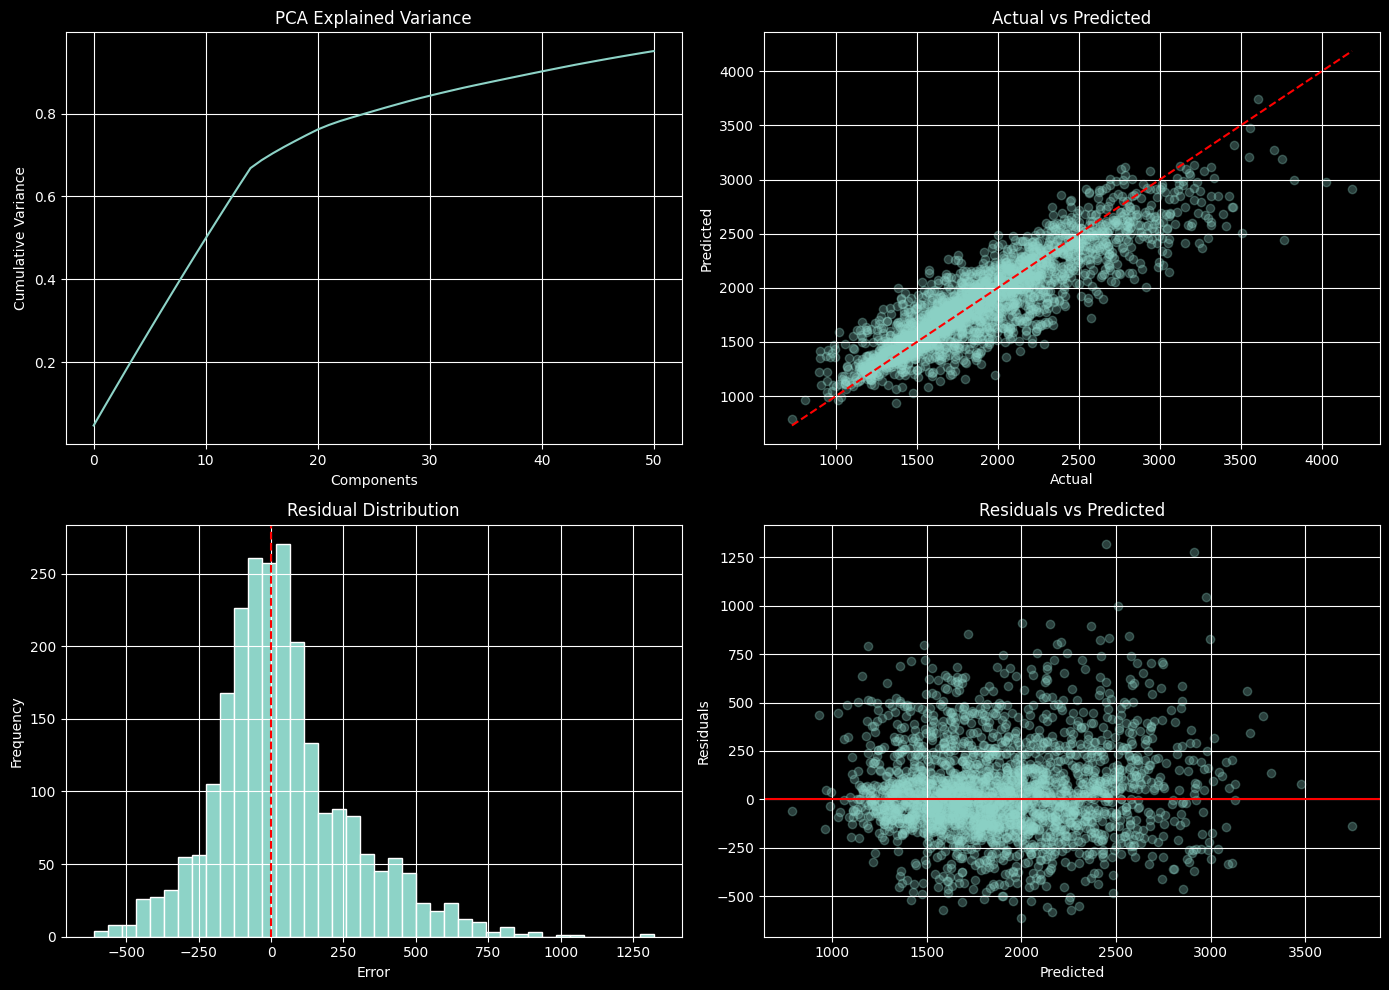

In [35]:
plt.style.use("dark_background")
plt.rcParams.update({
    "text.color": "white",
    "axes.labelcolor": "white",
    "axes.edgecolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.titlecolor": "white"
})


best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print("=" * 45)
print("       FINAL TEST SET EVALUATION")
print("=" * 45)
print(f"  R²   (Coefficient of Determination) : {r2:.4f}")
print(f"  MAE  (Mean Absolute Error)           : ${mae:,.2f}")
print(f"  RMSE (Root Mean Squared Error)       : ${rmse:,.2f}")
print("=" * 45)
print(f"\n→ The model explains {r2*100:.1f}% of price variance.")
print(f"→ On average, predictions are off by ~${mae:.0f}.")


pca_step = best_model.named_steps['pca']
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -1. PCA Explained Variance
axes[0, 0].plot(np.cumsum(pca_step.explained_variance_ratio_))
axes[0, 0].set_title("PCA Explained Variance")
axes[0, 0].set_xlabel("Components")
axes[0, 0].set_ylabel("Cumulative Variance")
axes[0, 0].grid(True)

# -2. Actual vs Predicted
axes[0, 1].scatter(y_test, y_pred, alpha=0.3)
axes[0, 1].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()],
                'r--')
axes[0, 1].set_title("Actual vs Predicted")
axes[0, 1].set_xlabel("Actual")
axes[0, 1].set_ylabel("Predicted")
axes[0, 1].grid(True)

# -3. Residual Distribution
axes[1, 0].hist(residuals, bins=40, edgecolor='white')
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].set_xlabel("Error")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(True)

# -4. Residuals vs Predicted
axes[1, 1].scatter(y_pred, residuals, alpha=0.3)
axes[1, 1].axhline(0, color='red')
axes[1, 1].set_title("Residuals vs Predicted")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Residuals")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

---
# Baseline Model
---

In [36]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

b_r2   = r2_score(y_test, dummy_pred)
b_mae  = mean_absolute_error(y_test, dummy_pred)
b_rmse = mean_squared_error(y_test, dummy_pred) ** 0.5

print(f"\n{'Metric':<8} {'Baseline (Mean Pred)':>22} {'SVR (Best Model)':>18}")
print("-" * 50)
print(f"{'R²':<8} {b_r2:>22.4f} {r2:>18.4f}")
print(f"{'MAE':<8} ${b_mae:>20,.2f} ${mae:>16,.2f}")
print(f"{'RMSE':<8} ${b_rmse:>20,.2f} ${rmse:>16,.2f}")
print(f"\n→ SVR improves R² by {(r2 - b_r2)*100:.1f} percentage points over baseline.")


Metric     Baseline (Mean Pred)   SVR (Best Model)
--------------------------------------------------
R²                      -0.0001             0.7724
MAE      $              399.10 $          173.59
RMSE     $              500.55 $          238.77

→ SVR improves R² by 77.3 percentage points over baseline.


---
# Complete Summary
---

In [38]:
best_model = grid_search.best_estimator_

print("Final trained pipeline:")
print(best_model)

print(f"\n{'='*50}")


Final trained pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['screen_size', 'ram_gb',
                                                   'storage_gb', 'year',
                                                   'weight_kg', 'battery_wh',
                                                   'refresh_rate_hz',
                                                   'cpu_cores', 'touchscreen',
                                                   'backlit_keyboard',
                                                   'fingerprint_reader',
                     

In [39]:
print("PIPELINE SUMMARY")
print(f"{'='*50}")
print(f"  Input features          : {X_train.shape[1]} (numeric + categorical)")
print(f"  Best C (regularisation) : {grid_search.best_params_['svr__C']}")
print(f"  CV R²  (train)          : {grid_search.best_score_:.4f}")
print(f"  R²     (test)           : {r2:.4f}")
print(f"  MAE    (test)           : ${mae:.2f}")
print(f"  RMSE   (test)           : ${rmse:.2f}")
print(f"{'='*50}")

PIPELINE SUMMARY
  Input features          : 25 (numeric + categorical)
  Best C (regularisation) : 10
  CV R²  (train)          : 0.7850
  R²     (test)           : 0.7724
  MAE    (test)           : $173.59
  RMSE   (test)           : $238.77
